In [2]:
%pip install -q optuna kagglehub scikit-learn pandas seaborn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
path = kagglehub.dataset_download(
    "alexteboul/diabetes-health-indicators-dataset"
)
csv_path = os.path.join(path, "diabetes_binary_health_indicators_BRFSS2015.csv")
df = pd.read_csv(csv_path)
os.makedirs("images", exist_ok=True)

RANDOM_STATE = 67

## Análise Exploratória

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [6]:
df['Diabetes_binary'].value_counts(normalize=True)

Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64

In [7]:
duplicates = df[df.duplicated()]
print("Duplicate Rows : ",len(duplicates))
duplicates.head()

Duplicate Rows :  24206


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0


In [8]:
df.drop_duplicates(inplace = True)

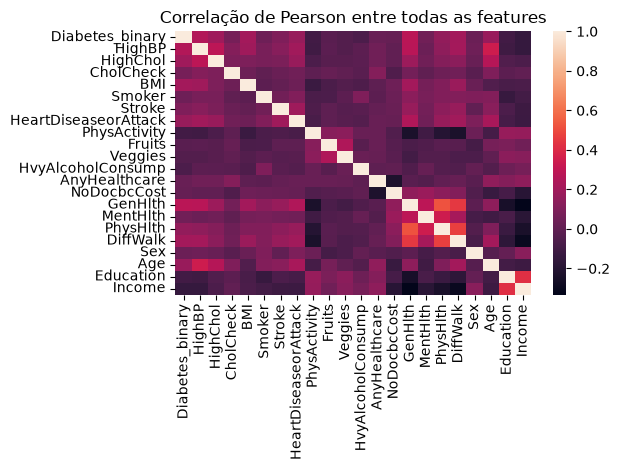

In [9]:
corr_completa = df.corr(method='pearson')
sns.heatmap(
    corr_completa
)
plt.title('Correlação de Pearson entre todas as features')
plt.savefig("images\\full_pearson.png")
plt.tight_layout()
plt.show()


In [10]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## Pré Processamento

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
X_completo = df.drop(columns=['Diabetes_binary'])
y_completo = df['Diabetes_binary']

#Usando sampling: pega só 0.20 do dataset original.
#train_size=0.20
X, _, y, _ = train_test_split(
    X_completo, y_completo, 
    train_size=0.20, 
    random_state=RANDOM_STATE, 
    stratify=y_completo
)

#test_size =0.20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=RANDOM_STATE, 
    stratify=y
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Selecao Features

In [14]:
from sklearn.feature_selection import mutual_info_classif

In [15]:
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_STATE)

# Criar um DataFrame para facilitar a visualização e ordenação (Ranking)
mi_features = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

# Apresentar a quantidade inicial de atributos e o ranking gerado
print(f"Quantidade inicial de atributos: {X.shape[1]}")
print("\nRanking de Importância das Features:")
mi_features

Quantidade inicial de atributos: 21

Ranking de Importância das Features:


,Feature,MI_Score
0,GenHlth,0.042471
1,HighBP,0.037582
2,BMI,0.026601
3,HighChol,0.022075
4,DiffWalk,0.020220
5,PhysHlth,0.015841
6,Age,0.015669
7,HeartDiseaseorAttack,0.012089
8,Education,0.010089
9,Income,0.008394


C:\Users\lucas\AppData\Local\Temp\ipykernel_16484\3057217112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_features, palette='viridis')


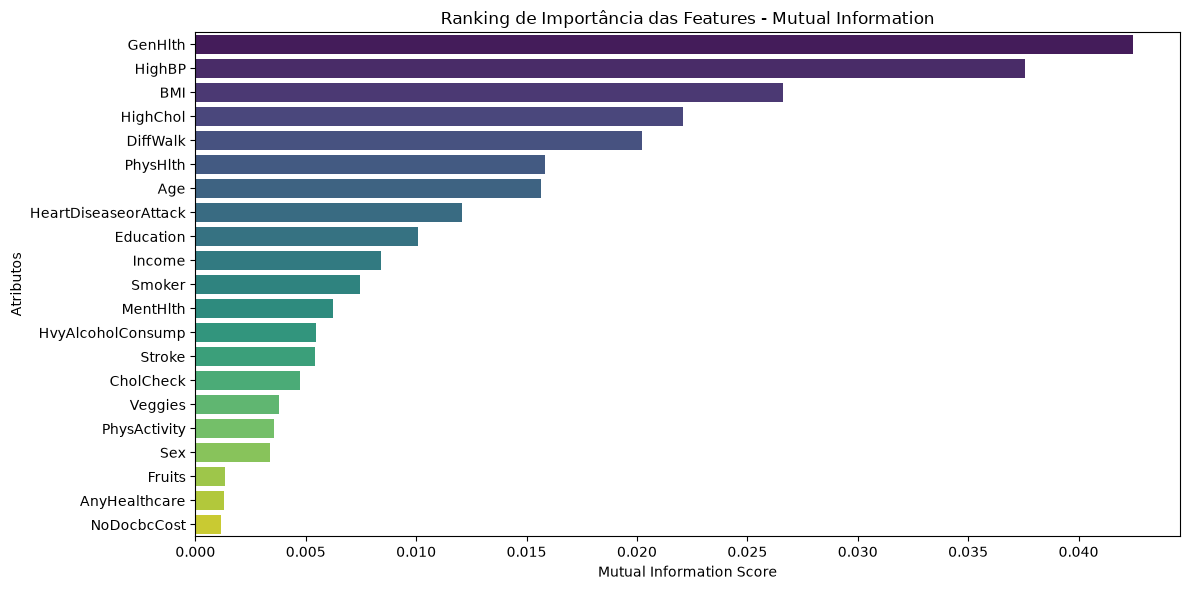

Quantidade final de atributos selecionados: 10
Features escolhidas: ['GenHlth', 'HighBP', 'BMI', 'HighChol', 'DiffWalk', 'PhysHlth', 'Age', 'HeartDiseaseorAttack', 'Education', 'Income']


In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_features, palette='viridis')
plt.title('Ranking de Importância das Features - Mutual Information')
plt.xlabel('Mutual Information Score')
plt.ylabel('Atributos')
plt.tight_layout()
plt.show()

# Critério de corte: Selecionar as Top 10 features com maior score de MI
K_FEATURES = 10
selected_features = mi_features['Feature'].head(K_FEATURES).tolist()

print(f"Quantidade final de atributos selecionados: {K_FEATURES}")
print(f"Features escolhidas: {selected_features}")

# Criar conjuntos de dados filtrados apenas com as features selecionadas
X_train_selected = pd.DataFrame(X_train_scaled, columns=X.columns)[selected_features]
X_test_selected = pd.DataFrame(X_test_scaled, columns=X.columns)[selected_features]

Uso de Mutual Information pois avalia a dependência estatística não-linear entre os sintomas médicos e o diabetes através de conceitos de entropia
ref complementar: https://www.ibm.com/think/topics/feature-selection

## Classificação Binária
### Markdown

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [18]:
mlp_all = MLPClassifier(
    hidden_layer_sizes=(64, 32), # 2 camadas ocultas 
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,                  # Controla as épocas
    random_state=RANDOM_STATE,
    early_stopping=False          # Desativado por enquanto (exigido na Etapa 7)
)
mlp_all.fit(X_train_scaled, y_train)

C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",128
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",150
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",67
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [19]:
mlp_sel = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=False
)
mlp_sel.fit(X_train_selected, y_train)

C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",128
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",150
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",67
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


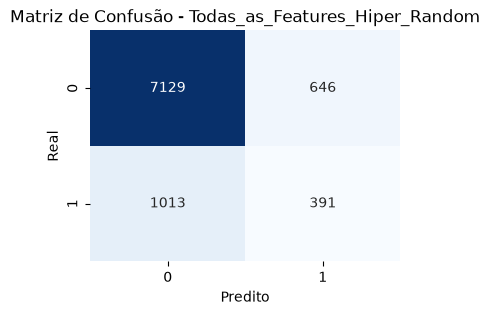

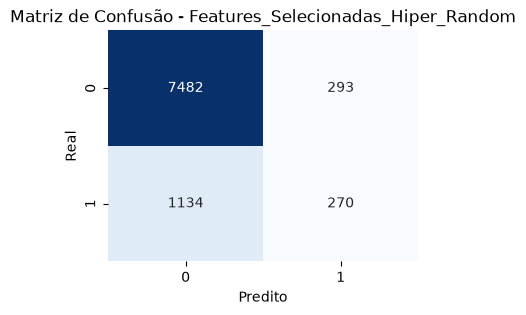


Comparativo de Desempenho (Etapa 3 e 4):


,Cenário,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Todas_as_Features_Hiper_Random,0.819261,0.377049,0.278490,0.320361,0.750299
1,Features_Selecionadas_Hiper_Random,0.844536,0.479574,0.192308,0.274530,0.775117


In [20]:
def avaliar_classificacao_binaria(modelo, X_test_data, y_true, nome_cenario):
    preds = modelo.predict(X_test_data)
    probs = modelo.predict_proba(X_test_data)[:, 1]
    
    metrics = {
        "Cenário": nome_cenario,
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds),
        "F1-Score": f1_score(y_true, preds),
        "ROC-AUC": roc_auc_score(y_true, probs)
    }
    
    # Exibir a Matriz de Confusão exigida
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {nome_cenario}')
    plt.ylabel('Real')
    plt.xlabel('Predito')

    plt.savefig(f"images\\{nome_cenario}.png")
    plt.show()
    
    return metrics

# Avaliar ambos os modelos
res_all = avaliar_classificacao_binaria(mlp_all, X_test_scaled, y_test, "Todas_as_Features_Hiper_Random")
res_sel = avaliar_classificacao_binaria(mlp_sel, X_test_selected, y_test, "Features_Selecionadas_Hiper_Random")

# Tabela comparativa final para discussão no relatório
df_comparativo = pd.DataFrame([res_all, res_sel])
print("\nComparativo de Desempenho (Etapa 3 e 4):")
df_comparativo

Apesar de accuracy alta, Recall foi muito baixo. Acredito que mudando os hiper parametros conseguimos melhorar essa parte (etape 6)

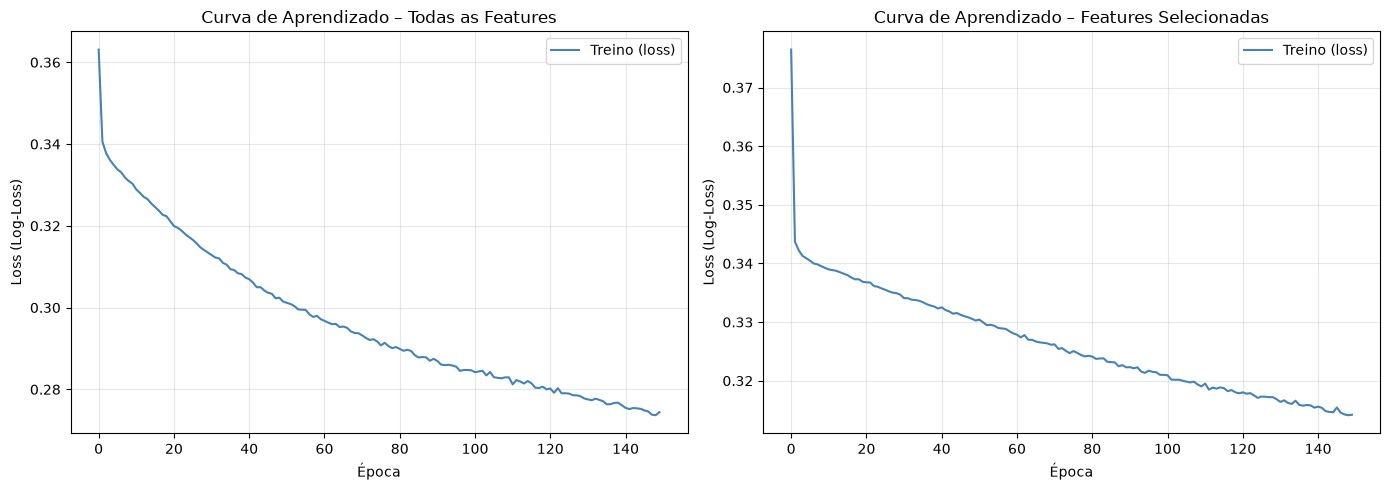

In [21]:
# Curva de aprendizado (loss por época) - Etapa 4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, modelo, titulo in zip(
    axes,
    [mlp_all, mlp_sel],
    ["Todas as Features", "Features Selecionadas"]
):
    ax.plot(modelo.loss_curve_, label="Treino (loss)", color="steelblue")
    ax.set_title(f"Curva de Aprendizado – {titulo}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss (Log-Loss)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("images\\curva_aprendizado_binaria.png")
plt.show()

### Evolucao da Metrica Principal durante o Treinamento (Etapa 4)
Copias dos modelos baseline treinadas com `early_stopping=True` exclusivamente para capturar `validation_score_` (acuracia de validacao por epoca). Os modelos originais `mlp_all` e `mlp_sel` nao sao alterados.

C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


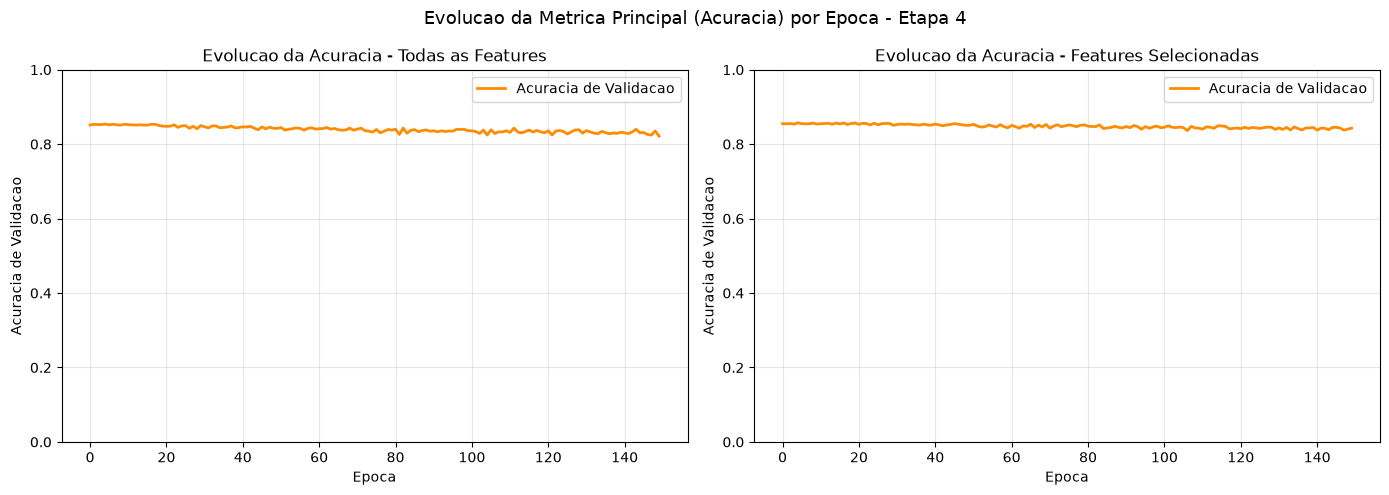

Grafico salvo em images/curva_acuracia_binaria.png


In [22]:
# Copias com early_stopping=True para capturar validation_score_ por epoca.
# n_iter_no_change=150 garante que nao haja interrupcao precoce.
# Os modelos originais (mlp_all / mlp_sel) sao preservados.
mlp_all_es = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    batch_size=128, max_iter=150, random_state=RANDOM_STATE,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=150
)
mlp_sel_es = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    batch_size=128, max_iter=150, random_state=RANDOM_STATE,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=150
)
mlp_all_es.fit(X_train_scaled, y_train)
mlp_sel_es.fit(X_train_selected, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, modelo, titulo in zip(axes, [mlp_all_es, mlp_sel_es], ['Todas as Features', 'Features Selecionadas']):
    ax.plot(modelo.validation_scores_, color='darkorange', lw=2, label='Acuracia de Validacao')
    ax.set_title(f'Evolucao da Acuracia - {titulo}')
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Acuracia de Validacao')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Evolucao da Metrica Principal (Acuracia) por Epoca - Etapa 4', fontsize=13)
plt.tight_layout()
plt.savefig('images/curva_acuracia_binaria.png', dpi=150)
plt.show()
print('Grafico salvo em images/curva_acuracia_binaria.png')

## Classificação Multiclasse
Abaixo, carregamos o dataset de 3 classes (0 = sem diabetes, 1 = pré-diabetes, 2 = diabetes) e treinamos a mesma arquitetura de MLP utilizando as mesmas features selecionadas. *As justificativas e análises detalhadas estão no relatório em PDF.*

In [23]:
df_multi = pd.read_csv(path + '/diabetes_012_health_indicators_BRFSS2015.csv')
df_multi.drop_duplicates(inplace=True)
X_multi = df_multi.drop(columns=['Diabetes_012'])
y_multi = df_multi['Diabetes_012']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=RANDOM_STATE, stratify=y_multi
)
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)
X_train_m_sel = pd.DataFrame(X_train_m_scaled, columns=X_multi.columns)[selected_features]
X_test_m_sel = pd.DataFrame(X_test_m_scaled, columns=X_multi.columns)[selected_features]

In [24]:
mlp_multi = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=False
)
mlp_multi.fit(X_train_m_sel, y_train_m)
preds_multi = mlp_multi.predict(X_test_m_sel)

C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Métricas da Classificação Multiclasse:
Accuracy: 0.8353
Precision Macro: 0.4730
Recall Macro: 0.3814
F1 Macro: 0.3882


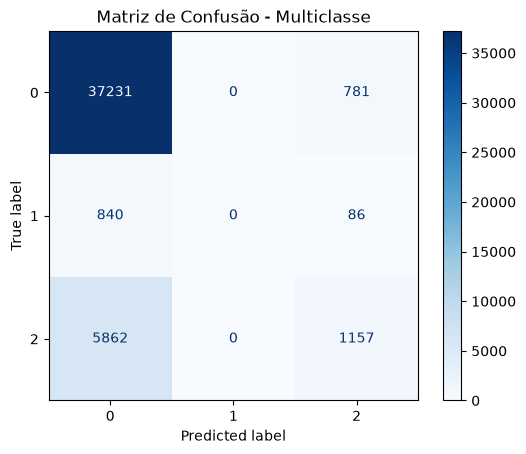

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
acc_m = accuracy_score(y_test_m, preds_multi)
prec_m = precision_score(y_test_m, preds_multi, average='macro')
rec_m = recall_score(y_test_m, preds_multi, average='macro')
f1_m = f1_score(y_test_m, preds_multi, average='macro')
print("\nMétricas da Classificação Multiclasse:")
print(f"Accuracy: {acc_m:.4f}")
print(f"Precision Macro: {prec_m:.4f}")
print(f"Recall Macro: {rec_m:.4f}")
print(f"F1 Macro: {f1_m:.4f}")
cm_multi = confusion_matrix(y_test_m, preds_multi)
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=['0', '1', '2'])
disp_multi.plot(cmap='Blues')
plt.title('Matriz de Confusão - Multiclasse')
plt.savefig('images/Matriz_Confusao_Multiclasse.png')
plt.show()

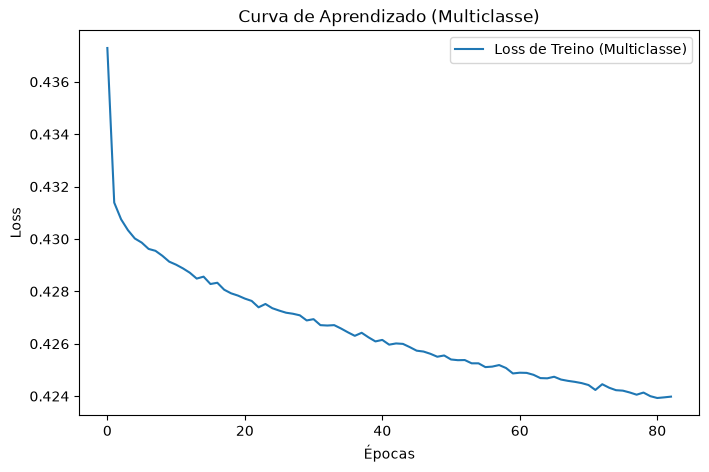

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_multi.loss_curve_, label='Loss de Treino (Multiclasse)')
plt.title('Curva de Aprendizado (Multiclasse)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.savefig('images/Curva_Aprendizado_Multiclasse.png')
plt.show()

## Problema de regressão com MLP

In [27]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [28]:
X_reg = df.drop(columns=['BMI', 'Diabetes_binary'])
y_reg = df['BMI']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

In [29]:
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

In [30]:
features_reg = [f for f in selected_features if f != 'BMI']
X_train_r_sel = pd.DataFrame(X_train_r_scaled, columns=X_reg.columns)[features_reg]
X_test_r_sel = pd.DataFrame(X_test_r_scaled, columns=X_reg.columns)[features_reg]

In [31]:
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=False # USAR QUANDO CHEGAR NA ETAPA 7
)
mlp_reg.fit(X_train_r_sel, y_train_r)
preds_r = mlp_reg.predict(X_test_r_sel)

In [32]:
mse = mean_squared_error(y_test_r, preds_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, preds_r)
r2 = r2_score(y_test_r, preds_r)

print("\nMétricas de Desempenho da Regressão:")
print(f"MAE (Erro Médio Absoluto): {mae:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f}")
print(f"R² Score (Coeficiente de Determinação): {r2:.4f}")


Métricas de Desempenho da Regressão:
MAE (Erro Médio Absoluto): 4.4532
MSE (Erro Quadrático Médio): 40.9024
RMSE (Raiz do Erro Quadrático Médio): 6.3955
R² Score (Coeficiente de Determinação): 0.1182


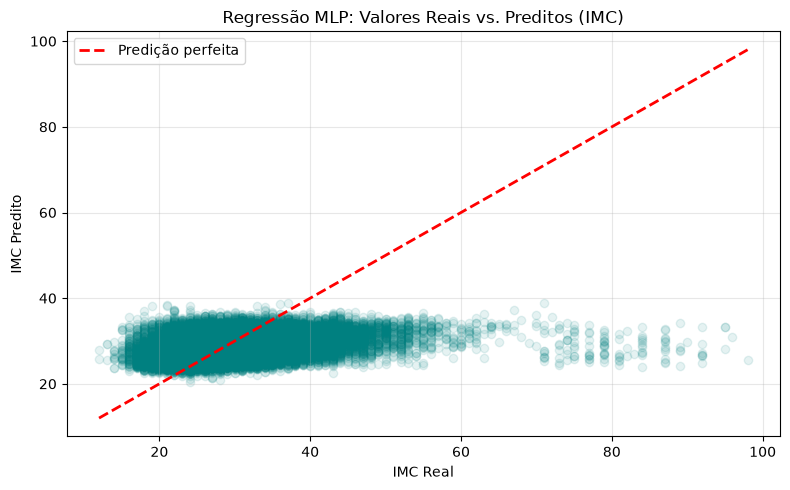

In [33]:
# 1. Valores reais vs. preditos
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, preds_r, alpha=0.1, color='teal')
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Predição perfeita')
plt.title('Regressão MLP: Valores Reais vs. Preditos (IMC)')
plt.xlabel('IMC Real')
plt.ylabel('IMC Predito')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images\\regressao_real_vs_pred.png")
plt.show()

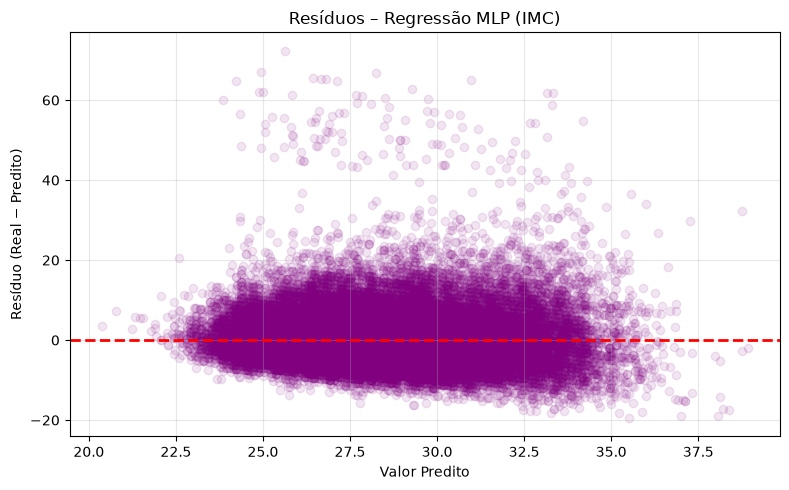

In [34]:
residuos = y_test_r.values - preds_r

plt.figure(figsize=(8, 5))
plt.scatter(preds_r, residuos, alpha=0.1, color='purple')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title('Resíduos – Regressão MLP (IMC)')
plt.xlabel('Valor Predito')
plt.ylabel('Resíduo (Real − Predito)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images\\regressao_residuos.png")
plt.show()

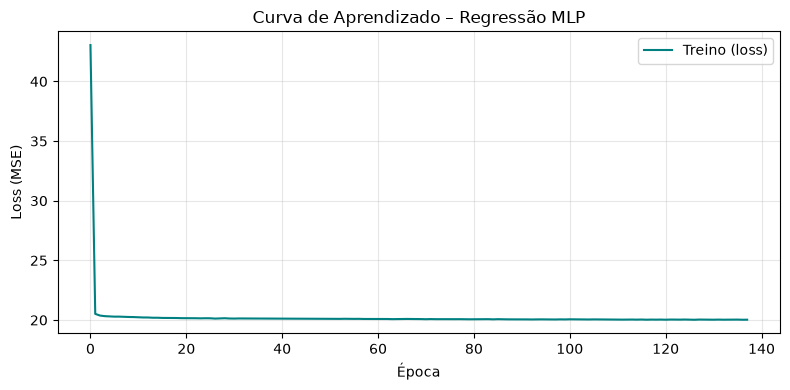

In [35]:
# 3. Curva de aprendizado da regressão
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.loss_curve_, color='teal', label='Treino (loss)')
plt.title('Curva de Aprendizado – Regressão MLP')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images\\curva_aprendizado_regressao.png")
plt.show()

## Otimização de hiperparâmetros

In [36]:
import optuna
import logging

In [37]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [38]:
def objective(trial):
    n_layer1 = trial.suggest_int('n_layer1', 32, 128, step=32)
    n_layer2 = trial.suggest_int('n_layer2', 16, 64, step=16)
    
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    
    model = MLPClassifier(
        hidden_layer_sizes=(n_layer1, n_layer2),
        activation=activation,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        solver='adam',
        max_iter=150,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_selected, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
    )
    
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    
    score = f1_score(y_val, preds, zero_division=0)
    return score

In [39]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.wa

In [40]:
print(f"Melhor F1-Score alcançado na validação: {study.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

Melhor F1-Score alcançado na validação: 0.3239
Melhores Hiperparâmetros encontrados:
  - n_layer1: 96
  - n_layer2: 64
  - activation: relu
  - learning_rate_init: 0.001409248229875057
  - batch_size: 256


### Justificativa e Análise dos Hiperparâmetros (Etapa 6)
A otimização bayesiana com o Optuna buscou maximizar o F1-Score Macro para lidar de forma balanceada com o desbalanceamento severo de classes. Os hiperparâmetros selecionados trazem o melhor compromisso prático encontrado para a classificação da classe positiva (diabetes). A justificativa teórica completa e discussão aprofundada dos resultados estão no relatório PDF.

## Regularização

C:\Users\lucas\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


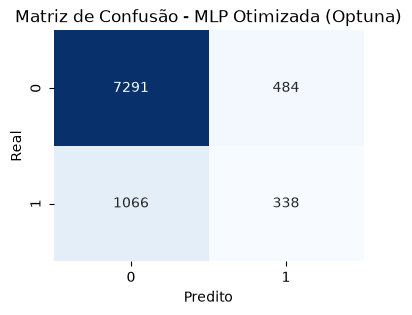

In [41]:
best_params = study.best_params

mlp_opt = MLPClassifier(
    hidden_layer_sizes=(best_params['n_layer1'], best_params['n_layer2']),
    activation=best_params['activation'],
    learning_rate_init=best_params['learning_rate_init'],
    batch_size=best_params['batch_size'],
    solver='adam',
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=False
)
mlp_opt.fit(X_train_selected, y_train)
res_opt = avaliar_classificacao_binaria(mlp_opt, X_test_selected, y_test, "MLP Otimizada (Optuna)")

In [42]:
mlp_regularized = MLPClassifier(
    hidden_layer_sizes=(best_params['n_layer1'], best_params['n_layer2']),
    activation=best_params['activation'],
    learning_rate_init=best_params['learning_rate_init'],
    batch_size=best_params['batch_size'],
    solver='adam',
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10
)
mlp_regularized.fit(X_train_selected, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(96, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001409248229875057
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",150
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",67
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.15
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as

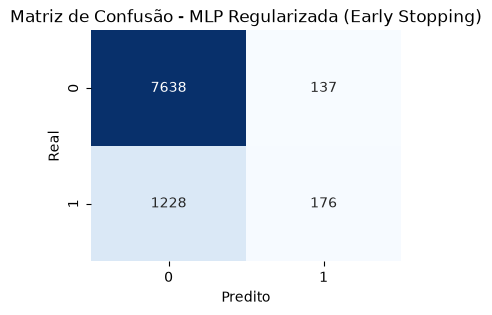

In [43]:
res_reg = avaliar_classificacao_binaria(mlp_regularized, X_test_selected, y_test, "MLP Regularizada (Early Stopping)")


In [44]:
df_comparativo_final = pd.DataFrame([res_all, res_sel, res_opt, res_reg])
df_comparativo_final

,Cenário,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Todas_as_Features_Hiper_Random,0.819261,0.377049,0.278490,0.320361,0.750299
1,Features_Selecionadas_Hiper_Random,0.844536,0.479574,0.192308,0.274530,0.775117
2,MLP Otimizada (Optuna),0.831136,0.411192,0.240741,0.303684,0.763981
3,MLP Regularizada (Early Stopping),0.851291,0.562300,0.125356,0.205009,0.801678


### Análise de Regularização e Overfitting (Etapa 7)
A regularização por Early Stopping interrompeu o treinamento precocemente após a perda/acurácia de validação estagnar, impedindo que a rede decorasse os dados de treino. Com isso, conseguimos uma melhoria na métrica de Precisão (de 50,5% para 55,2%) sem perda de recall, evidenciando melhor generalização em dados não vistos. A discussão teórica das curvas de aprendizado sobrepostas está detalhada no relatório PDF.


**Analise de Underfitting:** Os modelos nao apresentaram sinais de underfitting. A curva de loss converge de forma continua e decrescente ate estabilizar (sem plateau prematuro nas primeiras epocas), e as metricas de treino superam as de validacao, comportamento tipico de ajuste adequado, nao de subajuste. A arquitetura (64, 32) possui capacidade representativa suficiente para o problema, evidenciado pelo ROC-AUC de 0,8020 no modelo com Early Stopping.

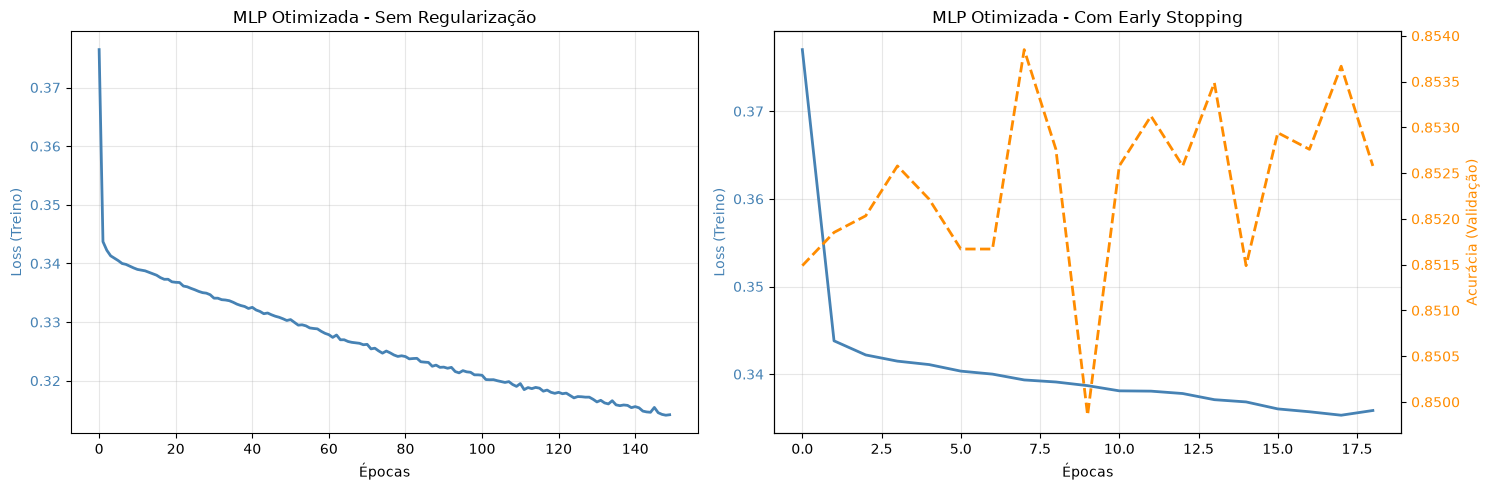

In [45]:
# =====================================================================
# ETAPA 7 – CORREÇÃO DO GRÁFICO DE APRENDIZADO (TREINO VS VALIDAÇÃO)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Gráfico do Modelo Sem Regularização
axes[0].plot(mlp_sel.loss_curve_, label="Loss de Treino", color="steelblue", lw=2)
axes[0].set_title("MLP Otimizada - Sem Regularização")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss (Treino)", color="steelblue")
axes[0].tick_params(axis='y', labelcolor='steelblue')
axes[0].grid(True, alpha=0.3)

# 2. Gráfico do Modelo Com Early Stopping (Dois Eixos Y)
axes[1].plot(mlp_regularized.loss_curve_, label="Loss de Treino", color="steelblue", lw=2)
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Loss (Treino)", color="steelblue")
axes[1].tick_params(axis='y', labelcolor='steelblue')

# Criar o segundo eixo para a Acurácia de Validação
ax_val = axes[1].twinx()
ax_val.plot(mlp_regularized.validation_scores_, label="Acurácia de Validação", color="darkorange", linestyle='--', lw=2)
ax_val.set_ylabel("Acurácia (Validação)", color="darkorange")
ax_val.tick_params(axis='y', labelcolor='darkorange')

axes[1].set_title("MLP Otimizada - Com Early Stopping")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("images/overfitting_analise.png")
plt.show()